<a href="https://colab.research.google.com/github/simaryadav/learning_roadmap/blob/main/bell_pepper_blight_prediction/Bell_pepper_blight_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from IPython import get_ipython
from IPython.display import display
import zipfile
import os
from tensorflow.keras import layers,models
import tensorflow as tf
import tensorflow.keras as keras
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Step1 : PREPROCESSING AND EDA

##Step 2: Extract and Use the Dataset

In [ ]:
import zipfile
import os

zip_path = "PlantVillage.zip"  # Adjust the path

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("PlantVillage")

# Remove the zip file
os.remove(zip_path)

print("Dataset extracted successfully!")


FileNotFoundError: [Errno 2] No such file or directory: 'PlantVillage.zip'

In [ ]:
ls

__MACOSX/  PlantVillage/


In [ ]:
cd PlantVillage/

/content/PlantVillage


In [ ]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    seed=123,
    shuffle=True,
    image_size=(256, 256),
    batch_size=32
)

Found 2475 files belonging to 2 classes.


In [ ]:
dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
class_names = dataset.class_names

In [ ]:
class_names

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy']

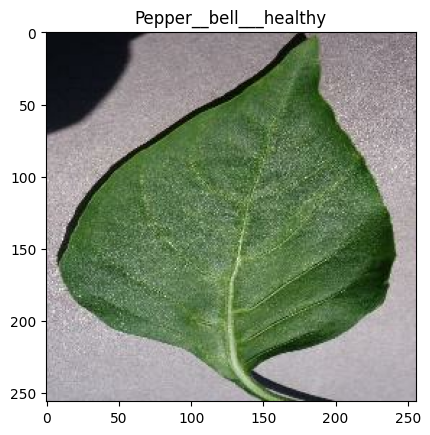

In [ ]:
for images, labels in dataset.take(1):
    plt.imshow(images[7].numpy().astype("uint8"))
    plt.title(class_names[labels[7].numpy()])
    plt.show()


In [ ]:
for image_batch,label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())
    print(image_batch[0].numpy())
    print(label_batch[0])

(32, 256, 256, 3)
[0 0 0 1 0 1 0 1 1 0 1 1 0 0 0 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1]
[[[142. 135. 142.]
  [149. 142. 149.]
  [152. 145. 152.]
  ...
  [133. 124. 129.]
  [134. 125. 130.]
  [112. 103. 108.]]

 [[146. 139. 146.]
  [151. 144. 151.]
  [155. 148. 155.]
  ...
  [ 83.  74.  79.]
  [126. 117. 122.]
  [116. 107. 112.]]

 [[146. 139. 146.]
  [147. 140. 147.]
  [152. 145. 152.]
  ...
  [131. 122. 127.]
  [111. 102. 107.]
  [109. 100. 105.]]

 ...

 [[166. 157. 160.]
  [187. 178. 181.]
  [176. 167. 170.]
  ...
  [130. 120. 119.]
  [108.  98.  97.]
  [132. 122. 121.]]

 [[152. 143. 146.]
  [173. 164. 167.]
  [159. 150. 153.]
  ...
  [112. 102. 101.]
  [114. 104. 103.]
  [140. 130. 129.]]

 [[177. 168. 171.]
  [203. 194. 197.]
  [171. 162. 165.]
  ...
  [112. 102. 101.]
  [124. 114. 113.]
  [129. 119. 118.]]]
tf.Tensor(0, shape=(), dtype=int32)


There's no train test split in tensorflow hence we manually split the datasets using the take and skip functions of tensors for our purpose

In [ ]:
train_size = 0.8
len(dataset)*train_size

62.400000000000006

In [ ]:
train_ds = dataset.take(62)
len(train_ds)

62

In [ ]:
test_ds = dataset.skip(62)
len(test_ds)

16

In [ ]:
val_size = 0.1
len(dataset)*val_size

7.800000000000001

In [ ]:
val_ds = test_ds.take(7)

In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

Data Preprocessing : This code defines a TensorFlow Sequential model that applies two preprocessing steps to images:

1️⃣ Resizing the image to (256, 256) pixels.
2️⃣ Rescaling pixel values from [0, 255] to [0, 1].

In [ ]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(256, 256),
    layers.Rescaling(1./255)
])

Data Augmentation : The code defines a data augmentation pipeline using tf.keras.Sequential(). Data augmentation artificially increases the size of the training dataset by applying random transformations to input images, helping the model generalize better.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

#Model Architecture
We use a CNN coupled with a Softmax activation in the output layer. We also add the initial layers for resizing, normalization and Data Augmentation.

In [ ]:
nclasses = 2
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3
EPOCHS=10
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)


model = models.Sequential([
        resize_and_rescale,
        data_augmentation,
        layers.Conv2D(32,(3,3),activation="relu",input_shape = input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(nclasses, activation='softmax'),

])

model.build(input_shape=input_shape)
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (32, 12, 12, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (32, 6, 6, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 4, 4, 64)              │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 2, 2, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 256)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 64)                    │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 2)                     │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 183,682 (717.51 KB)

 Trainable params: 183,682 (717.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer = "adam",
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ["accuracy"]
)

In [ ]:
history = model.fit(
    train_ds,
    batch_size = BATCH_SIZE,
    validation_data = val_ds,
    verbose = 1,
    epochs = 10
)

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 282s 5s/step - accuracy: 0.9908 - loss: 0.0360 - val_accuracy: 0.9955 - val_loss: 0.0130
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 285s 5s/step - accuracy: 0.9928 - loss: 0.0295 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 325s 5s/step - accuracy: 0.9944 - loss: 0.0137 - val_accuracy: 1.0000 - val_loss: 0.0094
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 316s 5s/step - accuracy: 0.9952 - loss: 0.0236 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 324s 5s/step - accuracy: 0.9971 - loss: 0.0112 - val_accuracy: 1.0000 - val_loss: 0.0098
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 287s 5s/step - accuracy: 0.9958 - loss: 0.0221 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 281s 5s/step - accuracy: 0.9953 - loss: 0.0139 - val_accuracy: 0.9955 - val_loss: 0.0167
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 323s 5s/step - accuracy: 0.9970 - loss: 0.0186 - val_accuracy: 0.9911 - v

In [ ]:
scores = model.evaluate(test_ds)

16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9903 - loss: 0.0177


In [ ]:
history.params

{'verbose': 1, 'epochs': 10, 'steps': 62}

In [ ]:
history.history['accuracy'][:5] # show loss for first 5 epochs

[0.992943525314331,
 0.9934476017951965,
 0.9944556355476379,
 0.9944556355476379,
 0.9949596524238586]

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

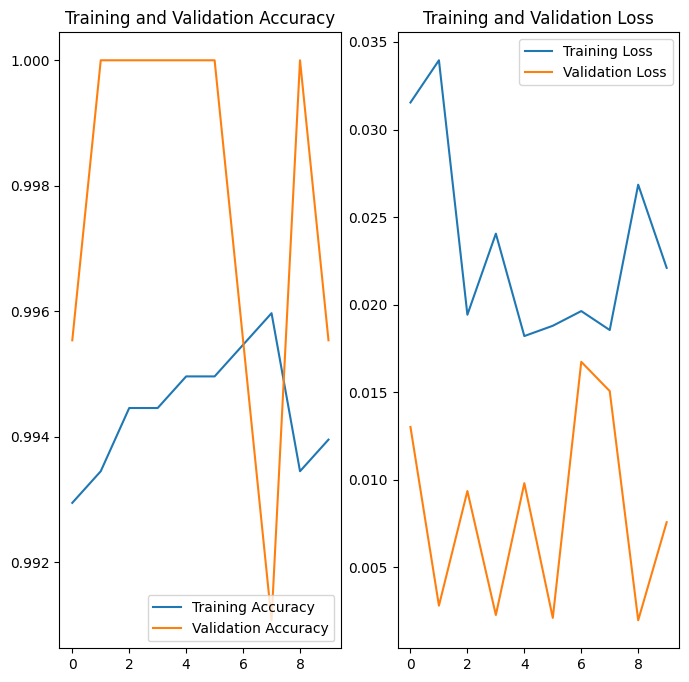

In [ ]:
EPOCHS=10

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#Run prediction on a sample image


first image to predict
actual label: Pepper__bell___healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
predicted label: Pepper__bell___healthy


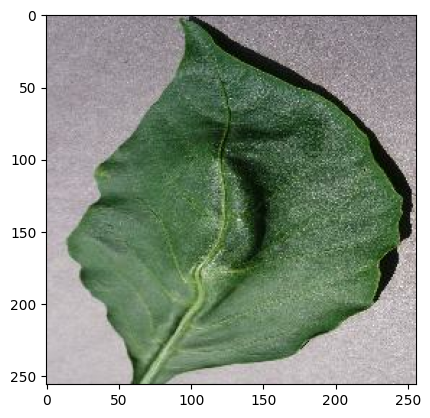

In [ ]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):

    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])

    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

Write a function for inference


In [ ]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

Now run inference on few sample images


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


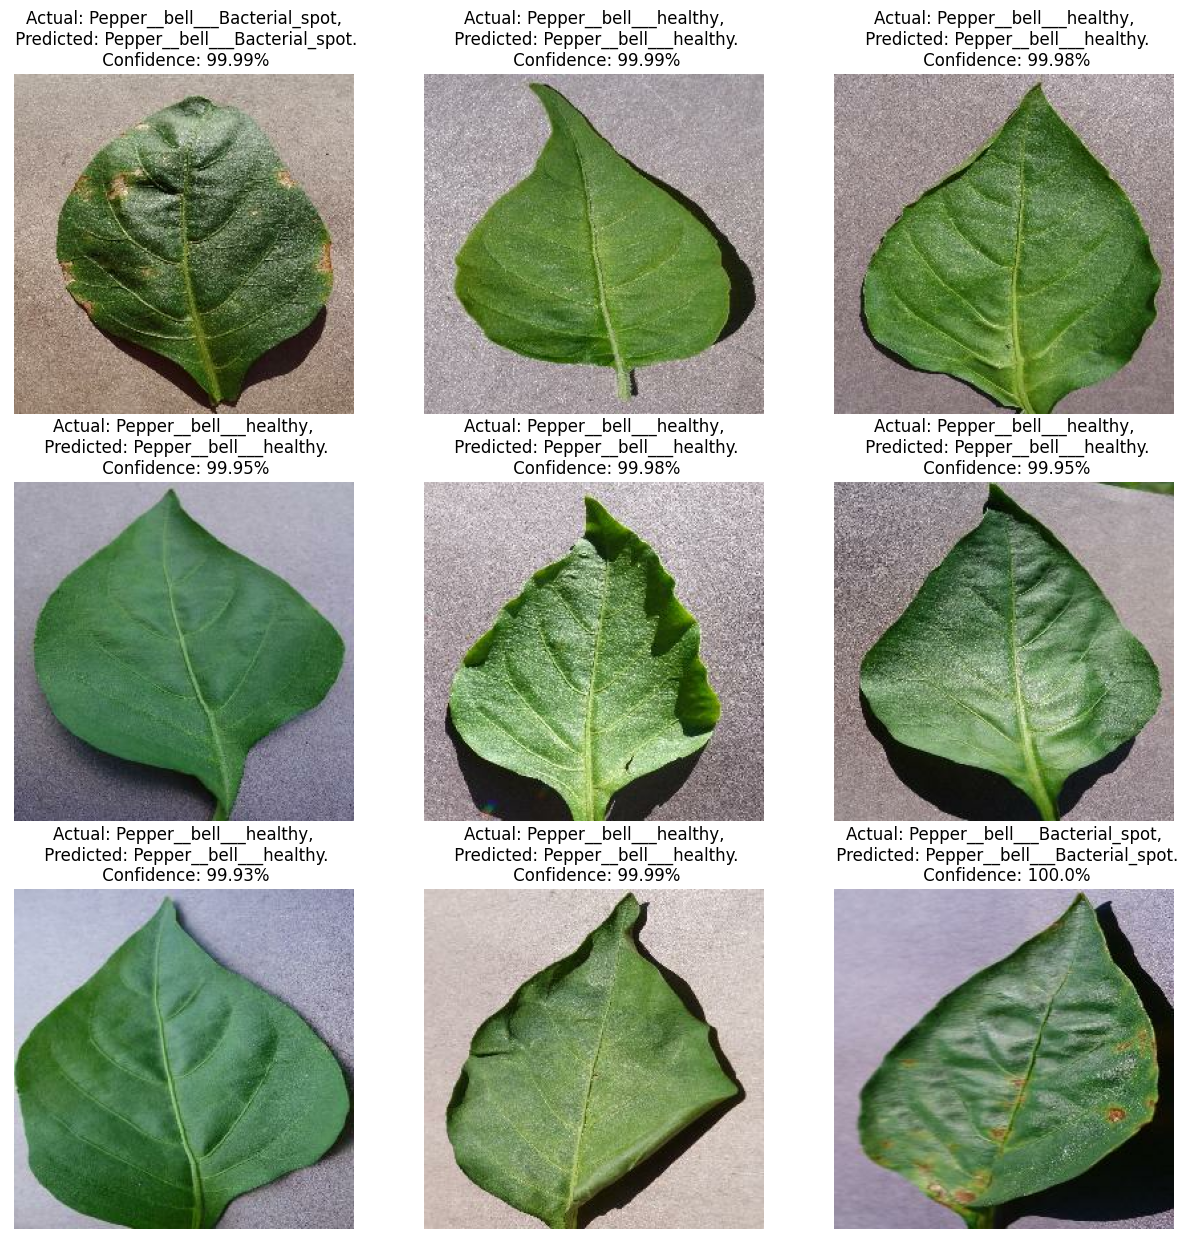

In [ ]:

plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis("off")

#Saving the Model


In [ ]:
import os
model.save("pepper_model.h5")